In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
import tempfile
import pickle as pkl
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from scipy.special import logit, softmax
from scipy.stats import wilcoxon, combine_pvalues

from one.api import ONE
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os
from os.path import join
from glob import glob
from tqdm import tqdm

In [4]:
df_final = pd.read_parquet("../data/collected_results/collected_results_stage3.pqt")

In [5]:
df_final

,region,n_sessions,pval_combined,n_units_mean,values_std,values_median,null_median_of_medians,valuesminusnull_median,frac_sig,values_median_sig,sig_combined,pval_combined_corrected,sig_combined_corrected
0,AAA,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
1,ACAd,21.0,0.000005,17.190476,0.149380,0.094276,0.035342,0.058935,0.428571,0.174525,True,0.000044,True
2,ACAv,11.0,0.000041,17.000000,0.159859,0.125084,0.022531,0.102554,0.454545,0.246183,True,0.000203,True
3,ACB,13.0,0.000013,18.846154,0.087639,0.050310,0.008797,0.041514,0.461538,0.139093,True,0.000088,True
4,AD,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,VPMpc,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
209,VTN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
210,ZI,26.0,0.000028,10.384615,0.157599,0.030308,0.012991,0.017317,0.269231,0.232479,True,0.000159,True
211,x,2.0,0.017183,9.500000,0.136777,0.124610,-0.014550,0.139160,0.500000,0.261387,True,0.031502,True


In [6]:
df_sessionfilter = df_final[df_final["n_sessions"] >= 1]

In [7]:
df_sessionfilter

,region,n_sessions,pval_combined,n_units_mean,values_std,values_median,null_median_of_medians,valuesminusnull_median,frac_sig,values_median_sig,sig_combined,pval_combined_corrected,sig_combined_corrected
0,AAA,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
1,ACAd,21.0,0.000005,17.190476,0.149380,0.094276,0.035342,0.058935,0.428571,0.174525,True,0.000044,True
2,ACAv,11.0,0.000041,17.000000,0.159859,0.125084,0.022531,0.102554,0.454545,0.246183,True,0.000203,True
3,ACB,13.0,0.000013,18.846154,0.087639,0.050310,0.008797,0.041514,0.461538,0.139093,True,0.000088,True
4,AD,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,VPMpc,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
209,VTN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
210,ZI,26.0,0.000028,10.384615,0.157599,0.030308,0.012991,0.017317,0.269231,0.232479,True,0.000159,True
211,x,2.0,0.017183,9.500000,0.136777,0.124610,-0.014550,0.139160,0.500000,0.261387,True,0.031502,True


In [8]:
from iblatlas.plots import plot_swanson_vector
import matplotlib as mpl
import seaborn as sns

In [9]:
mask = (df_sessionfilter["sig_combined_corrected"] == True) & (
    df_sessionfilter["values_median"] > 0
)

In [10]:
acronyms = df_sessionfilter["region"][mask].values
values = df_sessionfilter["valuesminusnull_median"][mask].values

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


(np.float64(0.0), np.float64(6820.0), np.float64(2968.0), np.float64(0.0))

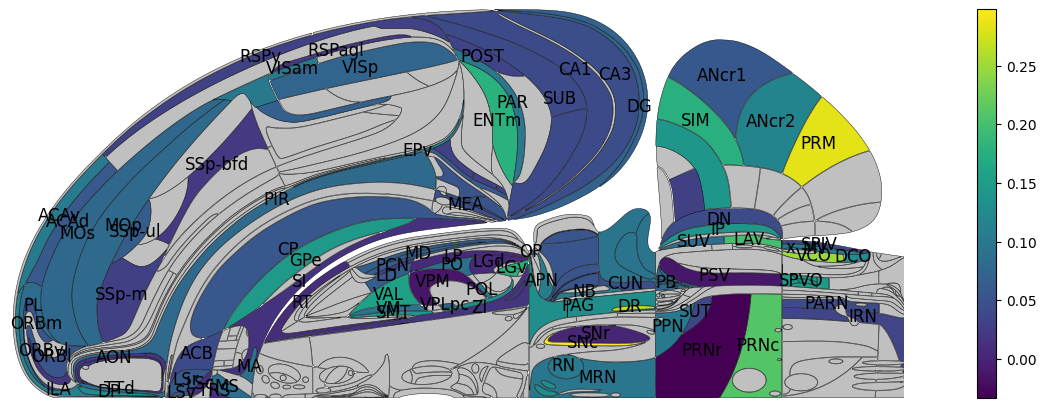

In [11]:
fig, ax = plt.subplots(figsize=(16, 4), layout="constrained")
cmap = mpl.cm.viridis
# cmap.set_extremes(under="cyan", over="magenta")
plot_swanson_vector(
    acronyms,
    values,
    ax=ax,
    cmap=cmap,
    annotate=True,
    annotate_list=acronyms,
    fontsize=12,
    empty_color="silver",
    mask=acronyms,
    mask_color="wheat",
    show_cbar=True,
)
ax.axis("off")

In [12]:
print(np.sum(df_sessionfilter["sig_combined_corrected"]))
print(len(df_sessionfilter))

104
213


In [13]:
np.sum(df_final["sig_combined_corrected"])

np.int64(104)

In [17]:
# get one running properly
from brainwidemap.bwm_loading import bwm_query, bwm_units, load_trials_and_mask, merge_probes

In [5]:
df_x = pd.read_parquet("../data/collected_results/collected_results_stage1.pqt")

In [8]:
sessionids = df_x["eid"].unique()

In [10]:
one = ONE()

In [23]:
pids_og, probes_og = one.eid2pid(sessionids[0])

In [18]:
bwm_df = bwm_query(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [19]:
session_data = bwm_df[bwm_df["eid"] == sessionids[0]]
pids = session_data["pid"].tolist()
probes = session_data["probe_name"].tolist()

In [24]:
pids

['80f6ffdd-f692-450f-ab19-cd6d45bfd73e',
 'ac839451-05bc-493e-b167-558b2b195baa']

In [25]:
pids_og

[UUID('80f6ffdd-f692-450f-ab19-cd6d45bfd73e'),
 UUID('ac839451-05bc-493e-b167-558b2b195baa')]